In [195]:
import os
import joblib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Metadata

## dirs and files structure

In [196]:
proj_root_path_from_jupyter_run_folder = '..'         # check if this is correct when running the jupyter notebook
proj_root = proj_root_path_from_jupyter_run_folder    # and let's make it shorter in usage further on

# EDA

## ids_relationship.csv

In [197]:
ids_rel_df = pd.read_csv(os.path.join(proj_root, 'data', 'ids_relationship.csv'))

ids_rel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 275124 entries, 0 to 275123
Data columns (total 3 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   id_ip                  275124 non-null  int64
 1   id_institution         275124 non-null  int64
 2   id_institution_subnet  275124 non-null  int64
dtypes: int64(3)
memory usage: 6.3 MB


### check if subnet id is unique within one institution, or uniqueness of subnet id is absolute

In [198]:
ids_rel_df['id_full_subnet'] = ids_rel_df.id_institution.map(str) + '_' + ids_rel_df.id_institution_subnet.map(str)

ids_rel_df.nunique(axis=0)


id_ip                    275124
id_institution              283
id_institution_subnet       548
id_full_subnet              552
dtype: int64

In [199]:
pd.DataFrame(ids_rel_df[['id_institution', 'id_institution_subnet']].value_counts(dropna=False).sort_index().head(20))

count
id_institution id_institution_subnet       
0              0                       2037
               1                          2
               2                          2
               3                          3
               4                        197
               5                          6
               6                       5111
               7                        124
               8                          6
               9                          5
               10                        27
               11                         1
               12                         1
               13                        35
               14                        42
               15                         8
1              16                        69
               17                     29288
2              18                       252
               19                         4

#### check if anonymization gave ids from 0 and without missing natural numbers

In [200]:
missing_ids_dict = {}

for fld in ids_rel_df.columns[:3]:
    missing_ids_dict[fld] = []
    check_set = set(ids_rel_df[fld].unique())
    for idx in range(ids_rel_df[fld].nunique()):
        if idx not in check_set:
            missing_ids_dict[fld].append(idx)

for fld in missing_ids_dict.keys():
    print('in the field', fld, 'there are', len(missing_ids_dict[fld]), 'misordered indexes')

in the field id_ip there are 210347 misordered indexes
in the field id_institution there are 2 misordered indexes
in the field id_institution_subnet there are 0 misordered indexes


### looks like `id_institution_subnet` is unique, but there are 4 unique pairs with institution, where subnets are shared by several institutions:

In [201]:
ids_rel_df.groupby('id_institution_subnet')['id_institution'].nunique().value_counts(dropna=False)

id_institution
1    544
2      4
Name: count, dtype: int64

#### actually 4 subnets do have second institution - let's see them:

In [202]:
ids_rel_df['nof_inst_per_subnet'] = ids_rel_df.groupby('id_institution_subnet')['id_institution'].transform('nunique')

ids_rel_df.query('nof_inst_per_subnet > 1'
                 )[['id_institution_subnet', 'id_institution']].value_counts(dropna=False).sort_index()

id_institution_subnet  id_institution
264                    69                124
                       279                 1
281                    81                  9
                       121                 8
345                    123                24
                       143                 8
359                    134                 2
                       280                 2
Name: count, dtype: int64

#### the true reasons behind are unclear - could be routing plans error, maliсious actions or just dedicated cross-institutional subnets for common distributed tasks.  For the moment we simply save them in a dictionary: 

In [203]:
tmp_df = ids_rel_df.query('nof_inst_per_subnet > 1').groupby('id_institution_subnet',
                                                             as_index=False)['id_institution'].agg('unique')
tmp_df.id_institution = tmp_df.id_institution.map(lambda npar: [int(n) for n in npar])  # getting rid of numpy types

shared_subnets_dict = dict(zip(tmp_df.id_institution_subnet, tmp_df.id_institution))
joblib.dump(shared_subnets_dict, os.path.join(proj_root, 'py_obj_saves', 'shared_subnets_dict.joblib'))
joblib.load(os.path.join(proj_root, 'py_obj_saves', 'shared_subnets_dict.joblib'))

{264: [69, 279], 281: [81, 121], 345: [123, 143], 359: [134, 280]}

### all ips id are unique, but let see how they split among institutions and subnets

In [204]:
ids_rel_df.groupby('id_institution').id_ip.agg('nunique').map(lambda x: np.log(x) / np.log(10)).describe()

count    283.000000
mean       1.234472
std        0.901347
min        0.000000
25%        0.698970
50%        1.041393
75%        1.462398
max        4.815020
Name: id_ip, dtype: float64

C:\Users\aseva\AppData\Local\Temp\ipykernel_16932\467979046.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend(title=('although anonymization used sequential numbers as IDs,\n' +


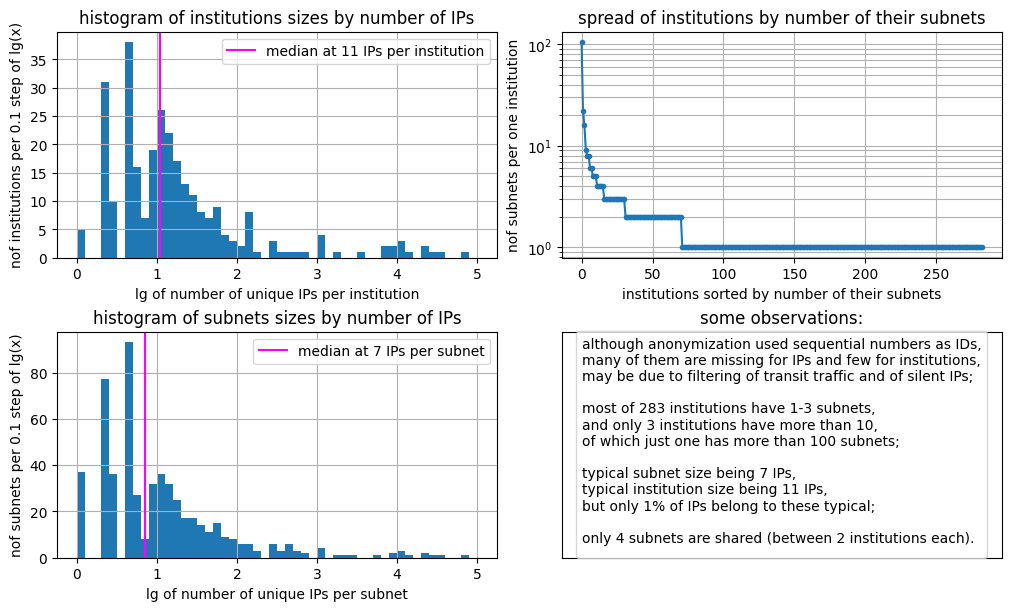

In [205]:
tmp_i_ser = ids_rel_df.groupby('id_institution').id_ip.agg('nunique').map(lambda x: np.log(x) / np.log(10))
median_i = ids_rel_df.groupby('id_institution').id_ip.agg('nunique').median()
tmp_s_ser = ids_rel_df.groupby('id_institution_subnet').id_ip.agg('nunique').map(lambda x: np.log(x) / np.log(10))
median_s = ids_rel_df.groupby('id_institution_subnet').id_ip.agg('nunique').median()
tmp_i_s = ids_rel_df.groupby('id_institution').id_institution_subnet.agg('nunique').sort_values(
                             ascending=False).reset_index(drop=True)
my_bins = np.arange(0, 5.1, 0.1)

fig, ax = plt.subplots(2, 2, figsize=(10, 6), layout='constrained')

ax[0, 0].hist(tmp_i_ser, bins=my_bins)
ax[0, 0].axvline(np.log(median_i) / np.log(10), color='magenta', 
                 label='median at '+ str(int(median_i)) + ' IPs per institution')
ax[0, 0].set_xlabel('lg of number of unique IPs per institution')
ax[0, 0].set_ylabel('nof institutions per 0.1 step of lg(x)')
ax[0, 0].set_title('histogram of institutions sizes by number of IPs')
ax[0, 0].grid()
ax[0, 0].legend()

ax[0, 1].plot(tmp_i_s.index, tmp_i_s.values, marker='.')
ax[0, 1].set_xlabel('institutions sorted by number of their subnets')
ax[0, 1].set_ylabel('nof subnets per one institution')
ax[0, 1].set_title('spread of institutions by number of their subnets')
ax[0, 1].set_yscale('log')
ax[0, 1].grid(which='both')

ax[1, 0].hist(tmp_s_ser, bins=my_bins)
ax[1, 0].axvline(np.log(median_s) / np.log(10), color='magenta', 
                 label='median at '+ str(int(median_s)) + ' IPs per subnet')
ax[1, 0].set_xlabel('lg of number of unique IPs per subnet')
ax[1, 0].set_ylabel('nof subnets per 0.1 step of lg(x)')
ax[1, 0].set_title('histogram of subnets sizes by number of IPs')
ax[1, 0].grid()
ax[1, 0].legend()

ax[1, 1].set_xticks([])
ax[1, 1].set_yticks([])
ax[1, 1].set_title('some observations:')
ax[1, 1].legend(title=('although anonymization used sequential numbers as IDs,\n' +
                       'many of them are missing for IPs and few for institutions,\n' +
                       'may be due to filtering of transit traffic and of silent IPs;\n\n' +
                       'most of 283 institutions have 1-3 subnets,\n' +
                       'and only 3 institutions have more than 10,\n' +
                       'of which just one has more than 100 subnets;\n\n' +
                       'typical subnet size being 7 IPs,\n' +
                       'typical institution size being 11 IPs,\n' +
                       'but only 1% of IPs belong to these typical;\n\n' +
                       'only 4 subnets are shared (between 2 institutions each).'),
                 loc='center')

## institutions folder

### `identifiers.csv` - looks like just a plain list of valid ids - let's check it

In [206]:
valid_inst_ids = pd.read_csv(os.path.join(proj_root, 'data', 'institutions','identifiers.csv')).iloc[:, 0].values

print(valid_inst_ids[0], len(valid_inst_ids), valid_inst_ids[-1])

0 283 284


#### looks like 2 are missing - NB!: as it was detected also in `ids_relationship.csv`

In [207]:

pd.Series(valid_inst_ids[1:] - valid_inst_ids[:-1]).value_counts(dropna=False)

1    280
2      2
Name: count, dtype: int64

#### definitely: two are missing, see which ones:

In [208]:

idx = pd.Series(valid_inst_ids[1:] - valid_inst_ids[:-1])

missing_inst_ids = [el+(i+1) for i,el in enumerate(list(idx[idx==2].index))]  # the gap augments by 1 at each new shift

joblib.dump(missing_inst_ids, os.path.join(proj_root, 'py_obj_saves', 'missing_institutes_list.joblib'))
joblib.load(os.path.join(proj_root, 'py_obj_saves', 'missing_institutes_list.joblib'))

[44, 174]

#### have a double check

In [209]:
# zero intersection of valid and missing IDs means that they are disjoint sets, which is what we expect
set(missing_inst_ids) & set(valid_inst_ids)


set()

In [210]:

# the union of valid and missing IDs should give us the whole range of IDs from 0 to the max ID
(set(missing_inst_ids) | set(valid_inst_ids)) == set(range(max(valid_inst_ids)+1))

True

### aggregated data subfolders

In [211]:
inst_files_list_agg_1_day  = os.listdir(os.path.join(proj_root, 'data', 'institutions', 'agg_1_day'))
inst_files_list_agg_1_hour = os.listdir(os.path.join(proj_root, 'data', 'institutions', 'agg_1_hour'))
inst_files_list_agg_10_min = os.listdir(os.path.join(proj_root, 'data', 'institutions', 'agg_10_minutes'))

len(inst_files_list_agg_1_day), len(inst_files_list_agg_1_hour), len(inst_files_list_agg_10_min)

(283, 283, 283)

### fields in data files

In [212]:
rand_inst = random.choice(valid_inst_ids)

ddf = pd.read_csv(os.path.join(proj_root, 'data', 'institutions', 'agg_1_day', f'{rand_inst}.csv'))
ddf.info()

<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_time                280 non-null    int64  
 1   n_flows                280 non-null    int64  
 2   n_packets              280 non-null    int64  
 3   n_bytes                280 non-null    int64  
 4   sum_n_dest_asn         280 non-null    int64  
 5   average_n_dest_asn     280 non-null    float64
 6   std_n_dest_asn         280 non-null    float64
 7   sum_n_dest_ports       280 non-null    int64  
 8   average_n_dest_ports   280 non-null    float64
 9   std_n_dest_ports       280 non-null    float64
 10  sum_n_dest_ip          280 non-null    int64  
 11  average_n_dest_ip      280 non-null    float64
 12  std_n_dest_ip          280 non-null    float64
 13  tcp_udp_ratio_packets  280 non-null    float64
 14  tcp_udp_ratio_bytes    280 non-null    float64
 15  dir_ratio_packets

**to understand the semantics on these data we have to read through the paper (which we partially site also below):**

Koumar, J., Hynek, K., Čejka, T. et al. CESNET-TimeSeries24: Time Series Dataset for Network Traffic Anomaly Detection and Forecasting. Sci Data 12, 338 (2025). https://doi.org/10.1038/s41597-025-04603-x

#### data serialization used:
the authors create evenly spaced time series for each IP address by aggregating IP flow records into time series datapoints. The created datapoints represent the behavior of IP addresses within a defined time window of 10 minutes. The vector of time-series metrics v_{ip, i} describes the IP address ip in the i-th time window. Thus, IP flows for vector v_{ip, i} are captured in time windows starting at t_i and ending at t_{i+1}. The time series are built from these datapoints.  

#### Datapoints created by the aggregation of IP flows contain the following time-series metrics:

* `Simple volumetric metrics`: the number of IP flows, the number of packets, and the transmitted data size (i.e. number of bytes)
* `Unique volumetric metrics`: the number of unique destination IP addresses, the number of unique destination Autonomous System Numbers (ASNs), and the number of unique destination transport layer ports.   
* `Ratios metrics`: the ratio of UDP/TCP packets, the ratio of UDP/TCP transmitted data size, the direction ratio of packets, and the direction ratio of transmitted data size
* `Average metrics`: the average flow duration, and the average Time To Live (TTL)

##### Multiple time aggregation:  
The original datapoints in the dataset are aggregated by 10 minutes of network traffic. The size of the aggregation interval influences anomaly detection procedures, mainly the training speed of the detection model. However, the 10-minute intervals can be too short for longitudinal anomaly detection methods. Therefore, we added two more aggregation intervals to the datasets--1 hour and 1 day.

##### Time series of institutions:  
We identify 283 institutions inside the CESNET3 network. These time series aggregated per each institution ID provide a view of the institution's data. 

##### Time series of institutional subnets: 
We identify 548 institution subnets inside the CESNET3 network. These time series aggregated per each institution ID provide a view of the institution subnet's data. 

#### description of time series data fields in CSV files:

* `id_time:`  Unique identifier for each aggregation interval within the time series, used to segment the dataset into specific time periods for analysis.
* `n_flows:` Total number of flows observed in the aggregation interval, indicating the volume of distinct sessions or connections for the IP address.
* `n_packets:` Total number of packets transmitted during the aggregation interval, reflecting the packet-level traffic volume for the IP address.
* `n_bytes:` Total number of bytes transmitted during the aggregation interval, representing the data volume for the IP address.
* `n_dest_ip:` Number of unique destination IP addresses contacted by the IP address during the aggregation interval, showing the diversity of endpoints reached.
* `n_dest_asn:` Number of unique destination Autonomous System Numbers (ASNs) contacted by the IP address during the aggregation interval, indicating the diversity of networks reached.
* `n_dest_port:` Number of unique destination transport layer ports contacted by the IP address during the aggregation interval, representing the variety of services accessed.
* `tcp_udp_ratio_packets:` Ratio of packets sent using TCP versus UDP by the IP address during the aggregation interval, providing insight into the transport protocol usage pattern. This metric belongs to the interval <0, 1> where 1 is when all packets are sent over TCP, and 0 is when all packets are sent over UDP.
* `tcp_udp_ratio_bytes:` Ratio of bytes sent using TCP versus UDP by the IP address during the aggregation interval, highlighting the data volume distribution between protocols. This metric belongs to the interval <0, 1>  with same rule as tcp_udp_ratio_packets.
* `dir_ratio_packets:` Ratio of packet directions (inbound versus outbound) for the IP address during the aggregation interval, indicating the balance of traffic flow directions. This metric belongs to the interval <0, 1>, where 1 is when all packets are sent in the outgoing direction from the monitored IP address, and 0 is when all packets are sent in the incoming direction to the monitored IP address.
* `dir_ratio_bytes:` Ratio of byte directions (inbound versus outbound) for the IP address during the aggregation interval, showing the data volume distribution in traffic flows. This metric belongs to the interval <0, 1> with the same rule as dir_ratio_packets.
* `avg_duration:` Average duration of IP flows for the IP address during the aggregation interval, measuring the typical session length.
* `avg_ttl:` Average Time To Live (TTL) of IP flows for the IP address during the aggregation interval, providing insight into the lifespan of packets.

##### if the time series created by re-aggregation it contains following metrics instead of `n_dest_ip`, `n_dest_asn`, and `n_dest_port`:

* `sum_n_dest_ip:` Sum of numbers of unique destination IP addresses.
* `avg_n_dest_ip:` The average number of unique destination IP addresses.
* `std_n_dest_ip:` Standard deviation of numbers of unique destination IP addresses.
* `sum_n_dest_asn:` Sum of numbers of unique destination ASNs.
* `avg_n_dest_asn:` The average number of unique destination ASNs.
* `std_n_dest_asn:` Standard deviation of numbers of unique destination ASNs.
* `sum_n_dest_port:` Sum of numbers of unique destination transport layer ports.
* `avg_n_dest_port:`  The average number of unique destination transport layer ports.
* `std_n_dest_port:` Standard deviation of numbers of unique destination transport layer ports.